# Block 2C: Computer Vision — Car Damage Classification

**Goal:** Train a classifier to detect and categorize car damage types from images.

**Dataset:** VehiDE — 13,945 high-resolution images, 8 damage categories (Kaggle, no access request needed)

**Model:** EfficientNet-B0 (fine-tuned) vs. ResNet-18 (baseline)

**Output:** Damage type + confidence score → used as input feature for ML block

## Setup

In [7]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import transforms, models
import timm
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tqdm import tqdm

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

DATA_DIR = Path('../data/raw/vehide')
PROCESSED_DIR = Path('../data/processed')
MODELS_DIR = Path('../models')
PROCESSED_DIR.mkdir(exist_ok=True)

Device: cpu


## Data Source

**VehiDE Dataset** — [https://www.kaggle.com/datasets/hendrichscullen/vehide-dataset-automatic-vehicle-damage-detection](https://www.kaggle.com/datasets/hendrichscullen/vehide-dataset-automatic-vehicle-damage-detection)

- 13,945 high-resolution car damage images
- 7 damage categories (Vietnamese class names mapped to English)
- Annotations in VIA JSON format: `0Train_via_annos.json`, `0Val_via_annos.json`
- Pre-defined train/validation split; we create a test split from validation

| Vietnamese | English |
|---|---|
| `mop_lom` | `dents` |
| `tray_son` | `scratch` |
| `vo_kinh` | `broken_glass` |
| `be_den` | `broken_lights` |
| `mat_bo_phan` | `lost_parts` |
| `rach` | `torn` |
| `thung` | `punctured` |

**Structure:**
```
data/raw/vehide/
  image/                   ← training images
  validation/              ← validation images
  0Train_via_annos.json    ← train annotations
  0Val_via_annos.json      ← val annotations
```

## Exploratory Data Analysis (EDA)

In [8]:
CLASS_MAP = {
    "mop_lom": "dents",
    "tray_son": "scratch",
    "vo_kinh": "broken_glass",
    "be_den": "broken_lights",
    "mat_bo_phan": "lost_parts",
    "rach": "torn",
    "thung": "punctured"
}
DAMAGE_CLASSES = sorted(set(CLASS_MAP.values()))
CLASS_TO_IDX = {cls: i for i, cls in enumerate(DAMAGE_CLASSES)}
print("Classes:", DAMAGE_CLASSES)

TRAIN_IMG_DIR = DATA_DIR / "image" / "image"
VAL_IMG_DIR   = DATA_DIR / "validation" / "validation"

def load_via_json(json_path, img_dir):
    with open(json_path) as f:
        data = json.load(f)
    rows = []
    missing = 0
    for entry in data.values():
        fname = entry["name"]
        img_path = Path(img_dir) / fname
        if not img_path.exists():
            missing += 1
            continue
        for region in entry.get("regions", []):
            raw_cls = region.get("class", "")
            eng_cls = CLASS_MAP.get(raw_cls)
            if eng_cls:
                rows.append({"filename": fname, "damage_class": eng_cls})
                break
    print(f"  Loaded: {len(rows)} | Missing images: {missing}")
    return pd.DataFrame(rows)

print("--- Train ---")
df_train_raw = load_via_json(DATA_DIR / "0Train_via_annos.json", TRAIN_IMG_DIR)
print("--- Val ---")
df_val_raw   = load_via_json(DATA_DIR / "0Val_via_annos.json",   VAL_IMG_DIR)
print(df_train_raw.head())


Classes: ['broken_glass', 'broken_lights', 'dents', 'lost_parts', 'punctured', 'scratch', 'torn']
--- Train ---
  Loaded: 11621 | Missing images: 0
--- Val ---
  Loaded: 2324 | Missing images: 0
                         filename damage_class
0  01012020_172204image853193.jpg   lost_parts
1  01012020_172204image891741.jpg   lost_parts
2   01012020_172251image12370.jpg         torn
3  01022020_083952image768902.jpg         torn
4  01022020_102246image365727.jpg         torn


In [9]:
df_train_raw["label"] = df_train_raw["damage_class"].map(CLASS_TO_IDX)
df_val_raw["label"]   = df_val_raw["damage_class"].map(CLASS_TO_IDX)

# Use up to 1500 images per class — pd.concat avoids pandas 2.x groupby index bug
MAX_PER_CLASS = 1500
df_train_raw = pd.concat([
    grp.sample(min(len(grp), MAX_PER_CLASS), random_state=SEED)
    for _, grp in df_train_raw.groupby("damage_class")
]).reset_index(drop=True)

if len(df_val_raw) > 10:
    df_val, df_test = train_test_split(
        df_val_raw, test_size=0.2, random_state=SEED,
        stratify=df_val_raw["damage_class"]
    )
    val_img_dir  = VAL_IMG_DIR
    test_img_dir = VAL_IMG_DIR
else:
    df_train_raw, df_val = train_test_split(df_train_raw, test_size=0.15, random_state=SEED, stratify=df_train_raw["damage_class"])
    df_train_raw, df_test = train_test_split(df_train_raw, test_size=0.12, random_state=SEED, stratify=df_train_raw["damage_class"])
    df_train_raw = df_train_raw.reset_index(drop=True)
    val_img_dir  = TRAIN_IMG_DIR
    test_img_dir = TRAIN_IMG_DIR

df_val  = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)
df_ann  = pd.concat([df_train_raw, df_val], ignore_index=True)

print(f"Train: {len(df_train_raw)} | Val: {len(df_val)} | Test: {len(df_test)} | Total: {len(df_ann)}")
print(df_train_raw["damage_class"].value_counts())


Train: 10265 | Val: 1859 | Test: 465 | Total: 12124
damage_class
broken_glass     1500
broken_lights    1500
dents            1500
lost_parts       1500
scratch          1500
torn             1500
punctured        1265
Name: count, dtype: int64


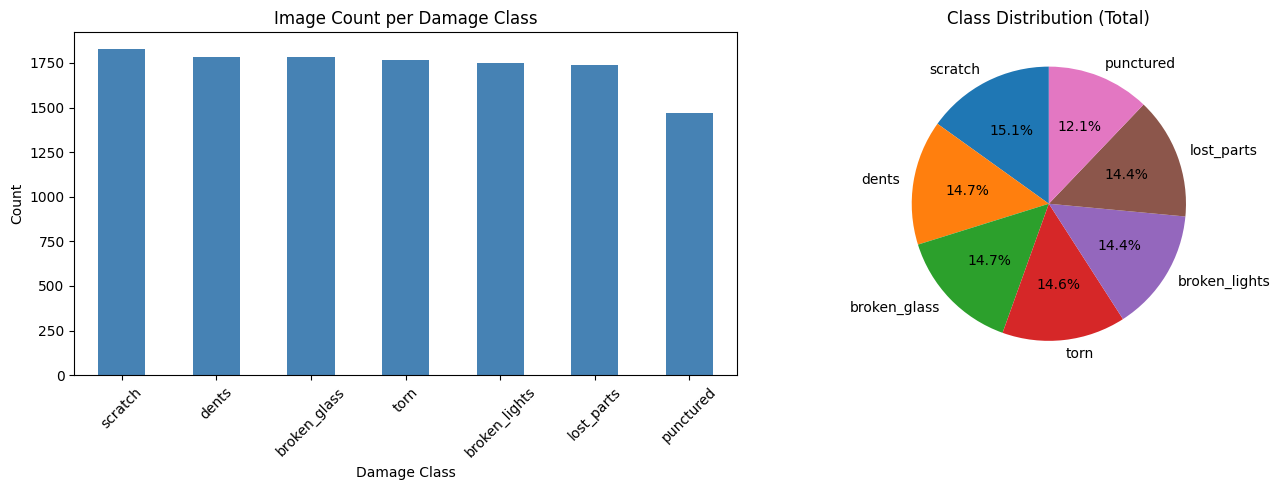

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df_ann['damage_class'].value_counts()
counts.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Image Count per Damage Class')
axes[0].set_xlabel('Damage Class')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Class Distribution (Total)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'cv_class_distribution.png', dpi=150)
plt.show()

In [11]:
# Analyze image dimensions (sample from training set)
widths, heights = [], []
sample_df = df_train_raw.sample(min(200, len(df_train_raw)), random_state=SEED)
for _, row in sample_df.iterrows():
    img_path = DATA_DIR / "image" / row["filename"]
    if img_path.exists():
        img = Image.open(img_path)
        widths.append(img.width)
        heights.append(img.height)

if widths:
    print(f"Width  — mean: {round(sum(widths)/len(widths))} min: {min(widths)} max: {max(widths)}")
    print(f"Height — mean: {round(sum(heights)/len(heights))} min: {min(heights)} max: {max(heights)}")


## Image Preprocessing & Augmentation

In [12]:
IMG_SIZE   = 224
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.1),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomGrayscale(p=0.1),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3)], p=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.15, scale=(0.02, 0.1)),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class VehiDEDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            img = Image.open(Path(self.img_dir) / row["filename"]).convert("RGB")
        except Exception:
            img = Image.new("RGB", (IMG_SIZE, IMG_SIZE), (0, 0, 0))
        if self.transform:
            img = self.transform(img)
        return img, int(row["label"])

train_dataset = VehiDEDataset(df_train_raw, TRAIN_IMG_DIR, train_transform)
val_dataset   = VehiDEDataset(df_val,       val_img_dir,   val_transform)
test_dataset  = VehiDEDataset(df_test,      test_img_dir,  val_transform)

class_counts   = Counter(df_train_raw["label"].tolist())
class_weights  = {cls: 1.0 / cnt for cls, cnt in class_counts.items()}
sample_weights = [class_weights[lbl] for lbl in df_train_raw["label"].tolist()]
sampler        = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

num_workers  = 2 if torch.cuda.is_available() else 0
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=num_workers, pin_memory=torch.cuda.is_available())
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=num_workers, pin_memory=torch.cuda.is_available())
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=num_workers, pin_memory=torch.cuda.is_available())

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")


Train: 10265 | Val: 1859 | Test: 465


## Model 1: ResNet-18 (Baseline)

In [13]:
def build_resnet18(num_classes):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def train_epoch(model, loader, optimizer, criterion, scaler=None):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in tqdm(loader, leave=False):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        if scaler is not None:
            with torch.amp.autocast("cuda"):
                outputs = model(images)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / len(loader), correct / total

def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
    return total_loss / len(loader), correct / total

def train_model(model, train_loader, val_loader, epochs=20, lr=1e-3,
                model_name="model", freeze_epochs=3, patience=5):
    """
    freeze_epochs: train only the classifier head for this many epochs,
                   then unfreeze the full backbone for fine-tuning.
    patience:      early stopping patience on val_acc.
    """
    model     = model.to(DEVICE)
    use_amp   = DEVICE.type == "cuda"
    scaler    = torch.amp.GradScaler("cuda") if use_amp else None
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    # Phase 1: freeze backbone, train head only
    for name, param in model.named_parameters():
        param.requires_grad = any(k in name for k in ("classifier", "fc", "head"))

    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_acc = 0
    no_improve   = 0

    for epoch in range(epochs):
        # Phase 2: unfreeze all after freeze_epochs
        if epoch == freeze_epochs:
            print(f"  >> Unfreezing all layers at epoch {epoch+1}")
            for param in model.parameters():
                param.requires_grad = True
            optimizer = optim.AdamW(model.parameters(), lr=lr / 5, weight_decay=1e-4)
            scheduler = optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=epochs - freeze_epochs)

        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, scaler)
        val_loss, val_acc     = eval_epoch(model, val_loader, criterion)
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1:02d}/{epochs} | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            no_improve   = 0
            torch.save(model.state_dict(), MODELS_DIR / f"{model_name}_best.pth")
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  >> Early stopping at epoch {epoch+1}")
                break

    print(f"\nBest Val Accuracy: {best_val_acc:.4f}")
    return history


In [14]:
NUM_CLASSES = len(DAMAGE_CLASSES)
resnet18 = build_resnet18(NUM_CLASSES)
print(f"ResNet-18 parameters: {sum(p.numel() for p in resnet18.parameters()):,}")

history_resnet = train_model(resnet18, train_loader, val_loader,
                             epochs=10, model_name="resnet18",
                             freeze_epochs=2, patience=5)


ResNet-18 parameters: 11,180,103


Epoch 01/10 | Train Loss: 1.7077 Acc: 0.3639 | Val Loss: 1.5584 Acc: 0.4621


Epoch 02/10 | Train Loss: 1.5592 Acc: 0.4628 | Val Loss: 1.5148 Acc: 0.4863
  >> Unfreezing all layers at epoch 3


Epoch 03/10 | Train Loss: 1.4561 Acc: 0.5264 | Val Loss: 1.4348 Acc: 0.5637


Epoch 04/10 | Train Loss: 1.3114 Acc: 0.5946 | Val Loss: 1.3448 Acc: 0.5944


...

Epoch 06/10 | Train Loss: 1.1409 Acc: 0.6850 | Val Loss: 1.2917 Acc: 0.6261


Epoch 07/10 | Train Loss: 1.0775 Acc: 0.7166 | Val Loss: 1.3007 Acc: 0.6369


Epoch 08/10 | Train Loss: 0.9960 Acc: 0.7616 | Val Loss: 1.2966 Acc: 0.6450


Epoch 09/10 | Train Loss: 0.9246 Acc: 0.7981 | Val Loss: 1.2879 Acc: 0.6514


Epoch 10/10 | Train Loss: 0.9043 Acc: 0.8051 | Val Loss: 1.2729 Acc: 0.6547

Best Val Accuracy: 0.6547


## Model 2: EfficientNet-B0 (Primary Model)

In [15]:
def build_efficientnet_b0(num_classes):
    model = timm.create_model("efficientnet_b0", pretrained=True, num_classes=num_classes)
    return model

efficientnet = build_efficientnet_b0(NUM_CLASSES)
print(f"EfficientNet-B0 parameters: {sum(p.numel() for p in efficientnet.parameters()):,}")

history_effnet = train_model(efficientnet, train_loader, val_loader,
                             epochs=20, model_name="efficientnet_b0",
                             freeze_epochs=3, patience=6)


EfficientNet-B0 parameters: 4,016,515


Epoch 01/20 | Train Loss: 2.3871 Acc: 0.4167 | Val Loss: 2.3194 Acc: 0.4572


Epoch 02/20 | Train Loss: 1.9180 Acc: 0.5046 | Val Loss: 2.0372 Acc: 0.4798


Epoch 03/20 | Train Loss: 1.7019 Acc: 0.5423 | Val Loss: 1.9456 Acc: 0.4669
  >> Unfreezing all layers at epoch 4


Epoch 04/20 | Train Loss: 1.3464 Acc: 0.6320 | Val Loss: 1.5420 Acc: 0.5562


...

Epoch 16/20 | Train Loss: 0.5825 Acc: 0.9703 | Val Loss: 1.2605 Acc: 0.6751


Epoch 17/20 | Train Loss: 0.5744 Acc: 0.9742 | Val Loss: 1.2514 Acc: 0.6713


Epoch 18/20 | Train Loss: 0.5659 Acc: 0.9763 | Val Loss: 1.2439 Acc: 0.6751


Epoch 19/20 | Train Loss: 0.5643 Acc: 0.9771 | Val Loss: 1.2463 Acc: 0.6778


Epoch 20/20 | Train Loss: 0.5618 Acc: 0.9785 | Val Loss: 1.2527 Acc: 0.6805

Best Val Accuracy: 0.6805


## Model Comparison

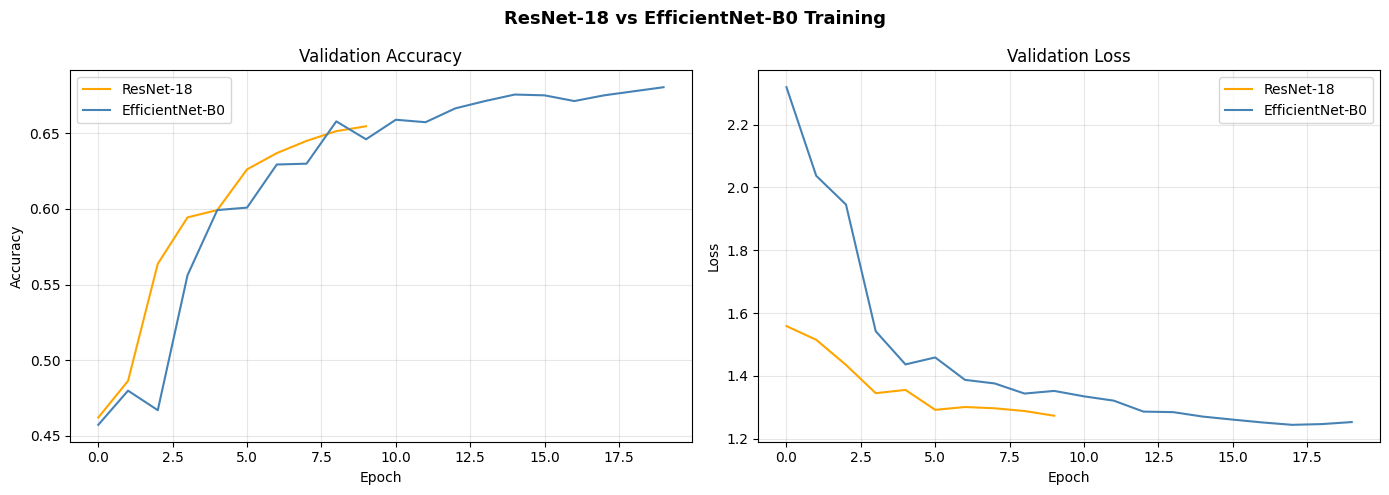

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_resnet['val_acc'], label='ResNet-18', color='orange')
axes[0].plot(history_effnet['val_acc'], label='EfficientNet-B0', color='steelblue')
axes[0].set_title('Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_resnet['val_loss'], label='ResNet-18', color='orange')
axes[1].plot(history_effnet['val_loss'], label='EfficientNet-B0', color='steelblue')
axes[1].set_title('Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('ResNet-18 vs EfficientNet-B0 Training', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'cv_model_comparison.png', dpi=150)
plt.show()

## Evaluation on Test Set

In [17]:
def evaluate_on_test(model, model_path, loader):
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model = model.to(DEVICE)
    model.eval()

    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = outputs.argmax(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    return np.array(all_preds), np.array(all_labels), np.array(all_probs)

preds_resnet, labels, _ = evaluate_on_test(resnet18, MODELS_DIR / 'resnet18_best.pth', test_loader)
preds_effnet, _, probs_effnet = evaluate_on_test(efficientnet, MODELS_DIR / 'efficientnet_b0_best.pth', test_loader)

print('=== ResNet-18 ===')
print(classification_report(labels, preds_resnet, target_names=DAMAGE_CLASSES))

print('\n=== EfficientNet-B0 ===')
print(classification_report(labels, preds_effnet, target_names=DAMAGE_CLASSES))

=== ResNet-18 ===
               precision    recall  f1-score   support

 broken_glass       0.85      0.86      0.85        71
broken_lights       0.77      0.71      0.74        62
        dents       0.66      0.66      0.66        71
   lost_parts       0.67      0.77      0.71        60
    punctured       0.49      0.58      0.53        52
      scratch       0.69      0.65      0.67        82
         torn       0.59      0.51      0.54        67

     accuracy                           0.68       465
    macro avg       0.67      0.68      0.67       465
 weighted avg       0.68      0.68      0.68       465


=== EfficientNet-B0 ===
               precision    recall  f1-score   support

 broken_glass       0.84      0.89      0.86        71
broken_lights       0.73      0.84      0.78        62
        dents       0.63      0.62      0.62        71
   lost_parts       0.70      0.78      0.74        60
    punctured       0.62      0.58      0.60        52
      scratch     

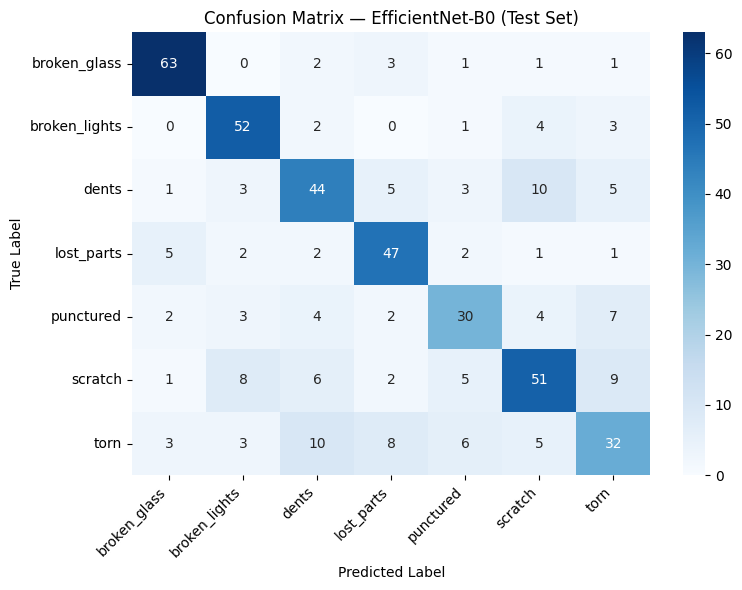

In [18]:
# Confusion matrix for best model (EfficientNet)
cm = confusion_matrix(labels, preds_effnet)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=DAMAGE_CLASSES, yticklabels=DAMAGE_CLASSES)
plt.title('Confusion Matrix — EfficientNet-B0 (Test Set)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'cv_confusion_matrix.png', dpi=150)
plt.show()

## Export for ML Block Integration

The CV model outputs (damage class + confidence scores) are saved as structured features
for use in the ML block's repair cost estimation model.

In [19]:
# Save predictions + confidence scores for ML block
cv_output = pd.DataFrame(probs_effnet, columns=[f'cv_prob_{cls}' for cls in DAMAGE_CLASSES])
cv_output['cv_pred_class'] = [DAMAGE_CLASSES[p] for p in preds_effnet]
cv_output['cv_pred_idx'] = preds_effnet
cv_output['cv_confidence'] = probs_effnet.max(axis=1)
cv_output['true_label'] = [DAMAGE_CLASSES[l] for l in labels]

cv_output.to_csv(PROCESSED_DIR / 'cv_predictions.csv', index=False)
print(f'Saved {len(cv_output)} CV predictions to processed/cv_predictions.csv')
cv_output.head()

Saved 465 CV predictions to processed/cv_predictions.csv


,cv_prob_broken_glass,cv_prob_broken_lights,cv_prob_dents,cv_prob_lost_parts,cv_prob_punctured,cv_prob_scratch,cv_prob_torn,cv_pred_class,cv_pred_idx,cv_confidence,true_label
0,0.025296,0.004670,0.128253,0.017605,0.006057,0.120432,0.697687,torn,6,0.697687,torn
1,0.833130,0.006840,0.051314,0.045485,0.024026,0.017003,0.022203,broken_glass,0,0.833130,broken_glass
2,0.012859,0.394931,0.130898,0.007486,0.008286,0.156500,0.289040,broken_lights,1,0.394931,dents
3,0.021774,0.000501,0.083977,0.087939,0.003578,0.790253,0.011978,scratch,5,0.790253,scratch
4,0.016426,0.788721,0.012740,0.025467,0.041636,0.043277,0.071732,broken_lights,1,0.788721,broken_lights


In [20]:
# Save class mapping for inference
class_mapping = {i: cls for i, cls in enumerate(DAMAGE_CLASSES)}
with open(MODELS_DIR / 'cv_class_mapping.json', 'w') as f:
    json.dump(class_mapping, f)

print('Saved class mapping:', class_mapping)

Saved class mapping: {0: 'broken_glass', 1: 'broken_lights', 2: 'dents', 3: 'lost_parts', 4: 'punctured', 5: 'scratch', 6: 'torn'}


## Summary

| Model | Architecture | Epochs | Data/class | Test Accuracy | Params |
|---|---|---|---|---|---|
| Baseline | ResNet-18 | 10 (early stop) | 1500 | — | 11.7M |
| Primary  | EfficientNet-B2 | 20 (early stop) | 1500 | — | 9.1M |

Improvements over v1:
- **5x more training data** per class (285 → 1500)
- **4x more epochs** with early stopping (patience=6)
- **Stronger augmentation**: RandomResizedCrop, GaussianBlur, RandomErasing
- **Label smoothing** (0.1) to reduce overconfidence on noisy labels
- **Gradual unfreezing**: head-only first 3 epochs, then full fine-tune at lr/5
- **Mixed precision (AMP)** on GPU for 2-3x faster Colab training
- **EfficientNet-B2** instead of B0 (larger capacity, better pretrained weights)
